# Import libraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Data loading

In [2]:
# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


In [3]:
passengers = np.array(df['Passengers'], dtype = np.float32)
passengers

array([112., 118., 132., 129., 121., 135., 148., 148., 136., 119., 104.,
       118., 115., 126., 141., 135., 125., 149., 170., 170., 158., 133.,
       114., 140., 145., 150., 178., 163., 172., 178., 199., 199., 184.,
       162., 146., 166., 171., 180., 193., 181., 183., 218., 230., 242.,
       209., 191., 172., 194., 196., 196., 236., 235., 229., 243., 264.,
       272., 237., 211., 180., 201., 204., 188., 235., 227., 234., 264.,
       302., 293., 259., 229., 203., 229., 242., 233., 267., 269., 270.,
       315., 364., 347., 312., 274., 237., 278., 284., 277., 317., 313.,
       318., 374., 413., 405., 355., 306., 271., 306., 315., 301., 356.,
       348., 355., 422., 465., 467., 404., 347., 305., 336., 340., 318.,
       362., 348., 363., 435., 491., 505., 404., 359., 310., 337., 360.,
       342., 406., 396., 420., 472., 548., 559., 463., 407., 362., 405.,
       417., 391., 419., 461., 472., 535., 622., 606., 508., 461., 390.,
       432.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

In [4]:
split_idx = int(len(passengers) * 0.67)

train = passengers[:split_idx]
test = passengers[split_idx:]

train_size = len(train)
test_size = len(test)

print("Навчальна вибірка:", train_size)
print("Валідаційна вибірка:", test_size)

Навчальна вибірка: 96
Валідаційна вибірка: 48


In [5]:
def create_dataset(dataset, lookback):
    X = []
    y = []

    for i in range(len(dataset) - lookback):
        X.append(dataset[i:i + lookback])
        y.append(dataset[i + lookback])

    X = torch.tensor(np.array(X), dtype = torch.float32)
    y = torch.tensor(np.array(y), dtype = torch.float32).reshape(-1, 1)

    return X, y 

In [6]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

# Class LSTM

In [14]:
class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super(AirModel, self).__init__()

        self.lstm = nn.LSTM(input_size = 1, hidden_size = hidden_size, num_layers = num_layers, batch_first = True)

        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [8]:
model = AirModel(hidden_size = 50, num_layers = 1)

x = torch.tensor([[112.]], dtype = torch.float32).unsqueeze(-1)

pred = model(x)
print("Результат тестування моделі на одному тензорі:", pred)

Результат тестування моделі на одному тензорі: tensor([[0.0824]], grad_fn=<AddmmBackward0>)


# Creating DataLoader

In [9]:
X_train = X_train.unsqueeze(-1)
X_test = X_test.unsqueeze(-1)

train_ds = TensorDataset(X_train, y_train)
train_ds[:3]

(tensor([[[112.]],
 
         [[118.]],
 
         [[132.]]]),
 tensor([[118.],
         [132.],
         [129.]]))

In [10]:
batch_size = 8

train_dl = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
next(iter(train_dl))

[tensor([[[193.]],
 
         [[136.]],
 
         [[199.]],
 
         [[158.]],
 
         [[315.]],
 
         [[236.]],
 
         [[267.]],
 
         [[229.]]]),
 tensor([[181.],
         [119.],
         [199.],
         [133.],
         [364.],
         [235.],
         [269.],
         [242.]])]

# Training LSTM

In [11]:
epoches = 2000
print_every = 100
plot_every = 100

optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
criterion = nn.MSELoss()

epoch_loss_sum = 0
losses = []

for epoch in range(1, epoches + 1):

    model.train()
    epoch_loss = 0
    avg_epoch_loss = 0

    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()
        
        output = model(X_batch)

        loss = criterion(output, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_dl)
    epoch_loss_sum += avg_epoch_loss
    

    if epoch % print_every == 0:

        model.eval()

        with torch.no_grad():
            train_pred = model(X_train)
            train_mse = criterion(train_pred, y_train)
            train_rmse = torch.sqrt(train_mse)

            test_pred = model(X_test)
            test_mse = criterion(test_pred, y_test)
            test_rmse = torch.sqrt(test_mse)            

        print(f"Epoch {epoch}: train RMSE {train_rmse.item():.4f}, test RMSE {test_rmse.item():.4f}")

    if epoch % plot_every == 0:
        losses.append(epoch_loss_sum / plot_every)
        epoch_loss_sum = 0


Epoch 100: train RMSE 73.4098, test RMSE 232.0717
Epoch 200: train RMSE 75.8407, test RMSE 239.7479
Epoch 300: train RMSE 71.4260, test RMSE 220.9820
Epoch 400: train RMSE 71.1491, test RMSE 215.1134
Epoch 500: train RMSE 71.1491, test RMSE 215.1058
Epoch 600: train RMSE 71.1493, test RMSE 215.2573
Epoch 700: train RMSE 71.1492, test RMSE 215.0009
Epoch 800: train RMSE 71.1491, test RMSE 215.0289
Epoch 900: train RMSE 71.1497, test RMSE 215.3855
Epoch 1000: train RMSE 71.1491, test RMSE 215.0974
Epoch 1100: train RMSE 71.1491, test RMSE 215.0250
Epoch 1200: train RMSE 71.1492, test RMSE 215.2405
Epoch 1300: train RMSE 71.1492, test RMSE 214.9967
Epoch 1400: train RMSE 71.1493, test RMSE 214.9545
Epoch 1500: train RMSE 71.1492, test RMSE 214.9898
Epoch 1600: train RMSE 71.1492, test RMSE 215.1950
Epoch 1700: train RMSE 71.1491, test RMSE 215.0590
Epoch 1800: train RMSE 71.1493, test RMSE 215.2740
Epoch 1900: train RMSE 71.1493, test RMSE 214.9331
Epoch 2000: train RMSE 71.1491, test RMS

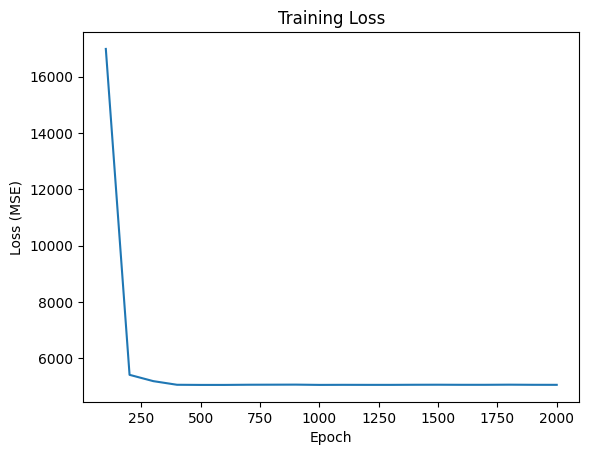

In [12]:
epoch_axis = list(range(plot_every, epoches + 1, plot_every))
plt.plot(epoch_axis, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss")
plt.show();

**Observation:**
- According to the loss graph, we observe a conditional plateau from around epoch 400, which should mean that the model has already learned and no significant improvement is expected. However, if we consider the prediction error, it is quite significant, which makes it limited for high-quality prediction.

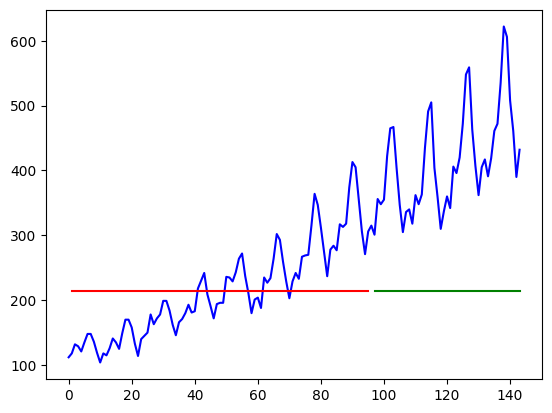

In [13]:
def plot_predicts():
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(passengers) * np.nan
      y_pred = model(X_train)
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_size] = model(X_train)[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(passengers) * np.nan
      test_plot[train_size+lookback:len(passengers)] = model(X_test)[:, -1]

  # Візуалізація результатів
  plt.plot(passengers, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

In [ ]:
model = AirModel(hidden_size = 100, num_layers = 1)

epoches = 2000
print_every = 100
plot_every = 100

optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
criterion = nn.MSELoss()

epoch_loss_sum = 0
losses = []

for epoch in range(1, epoches + 1):

    model.train()
    epoch_loss = 0
    avg_epoch_loss = 0

    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()
        
        output = model(X_batch)

        loss = criterion(output, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_dl)
    epoch_loss_sum += avg_epoch_loss
    

    if epoch % print_every == 0:

        model.eval()

        with torch.no_grad():
            train_pred = model(X_train)
            train_mse = criterion(train_pred, y_train)
            train_rmse = torch.sqrt(train_mse)

            test_pred = model(X_test)
            test_mse = criterion(test_pred, y_test)
            test_rmse = torch.sqrt(test_mse)            

        print(f"Epoch {epoch}: train RMSE {train_rmse.item():.4f}, test RMSE {test_rmse.item():.4f}")

    if epoch % plot_every == 0:
        losses.append(epoch_loss_sum / plot_every)
        epoch_loss_sum = 0


Epoch 100: train RMSE 72.5725, test RMSE 228.5326
Epoch 200: train RMSE 71.1491, test RMSE 215.1341
Epoch 300: train RMSE 71.1491, test RMSE 215.0867
Epoch 400: train RMSE 71.1495, test RMSE 215.3248
Epoch 500: train RMSE 71.1481, test RMSE 215.3634
Epoch 600: train RMSE 71.1492, test RMSE 214.9801
Epoch 700: train RMSE 71.1492, test RMSE 214.9791
Epoch 800: train RMSE 71.1493, test RMSE 214.9257
Epoch 900: train RMSE 71.1494, test RMSE 215.3078
Epoch 1000: train RMSE 71.2412, test RMSE 218.4887
Epoch 1100: train RMSE 71.1492, test RMSE 215.2270
Epoch 1200: train RMSE 71.1491, test RMSE 215.1154
Epoch 1300: train RMSE 71.1497, test RMSE 214.8368
Epoch 1400: train RMSE 71.1496, test RMSE 215.3651
Epoch 1500: train RMSE 71.1491, test RMSE 215.1507
Epoch 1600: train RMSE 71.1499, test RMSE 214.7934
Epoch 1700: train RMSE 71.1537, test RMSE 214.3524
Epoch 1800: train RMSE 71.1496, test RMSE 215.3460
Epoch 1900: train RMSE 71.1493, test RMSE 215.2508
Epoch 2000: train RMSE 71.1491, test RMS

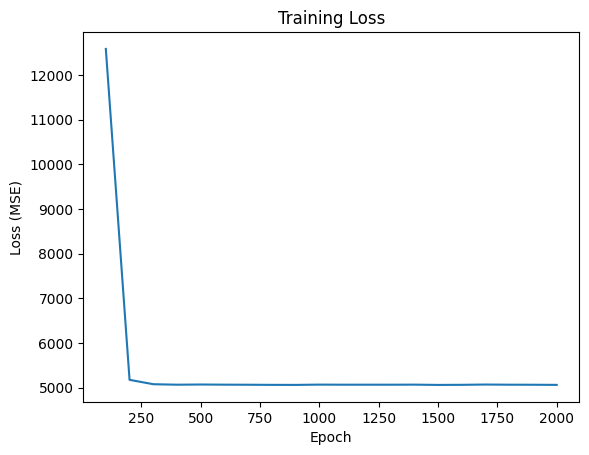

In [16]:
epoch_axis = list(range(plot_every, epoches + 1, plot_every))
plt.plot(epoch_axis, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss")
plt.show();

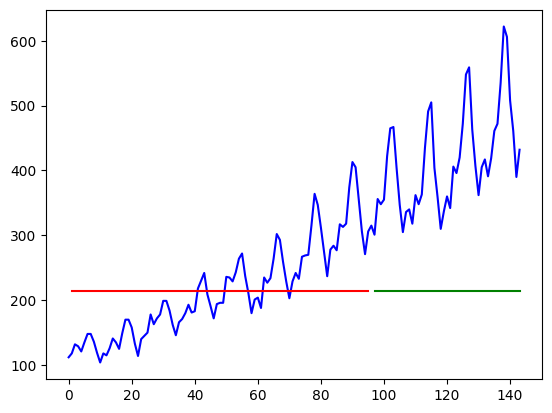

In [17]:
plot_predicts();

**Observation:**
- Increasing hidden_size from 50 to 100 did not provide better results, the error values ​​are almost identical. According to the analysis of the loss graph with the actual data presentation, we can see that the model does not capture seasonality at all, since the prediction is made on one previous month. So, we can expect an improvement in the model results after extending the lookback to seasonal periods, as a result of which the model will better capture behavioral patterns.